<>:5: SyntaxWarning: invalid escape sequence '\R'
<>:5: SyntaxWarning: invalid escape sequence '\R'
C:\Users\svetl\AppData\Local\Temp\ipykernel_1416\4176898525.py:5: SyntaxWarning: invalid escape sequence '\R'
  df = pd.read_csv("../../Exercise_project_1\Regression_dataset\housing_modified.csv")


<Axes: xlabel='median_house_value', ylabel='Count'>

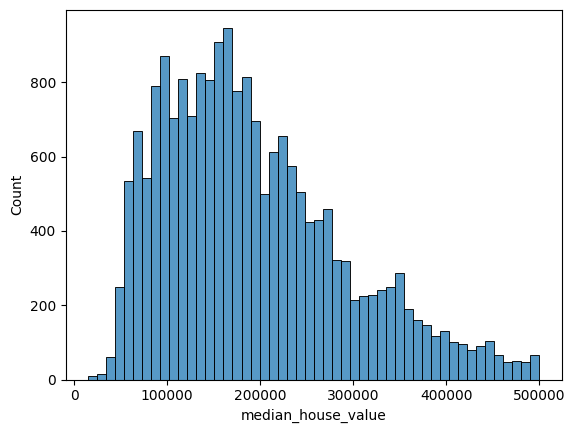

In [100]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../../Exercise_project_1\Regression_dataset\housing_modified.csv")

# for further analysis I will delete extreme values of target variable as it was already detected:
df = df.query("median_house_value < median_house_value.quantile(0.98)")

# now it looks better:
sns.histplot(df['median_house_value'])




<Axes: xlabel='housing_median_age', ylabel='Count'>

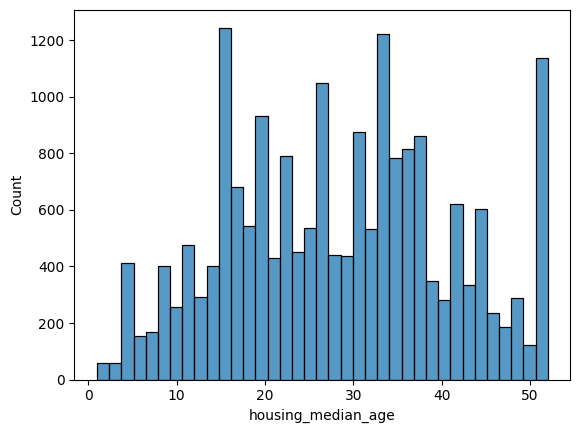

In [101]:
# housing_median_age large spike at the right edge gone, now distrubution looks like this:
sns.histplot(df['housing_median_age'])

In [102]:
# I will drop "households", "total_bedrooms" because of multicollinearity and to have less variables to inspect.
df.drop(columns=["households", "total_bedrooms"], inplace=True)

In [103]:
# trimming total_rooms and population variables:
df = df.query("total_rooms < total_rooms.quantile(0.97)")
df = df.query("population < population.quantile(0.97)")



<Axes: xlabel='total_rooms', ylabel='Count'>

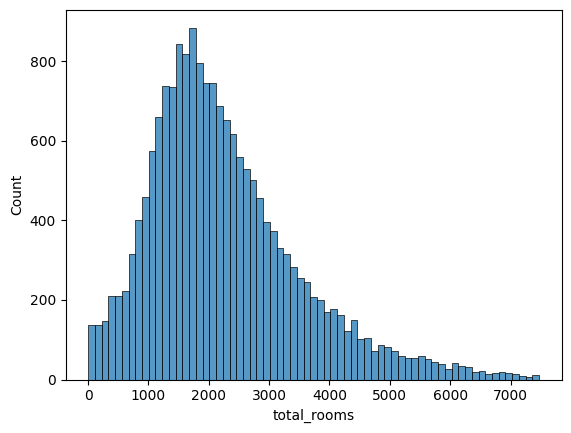

In [104]:
# still there is a tail but not that long as it was 
sns.histplot(df['total_rooms'])

<Axes: xlabel='population', ylabel='Count'>

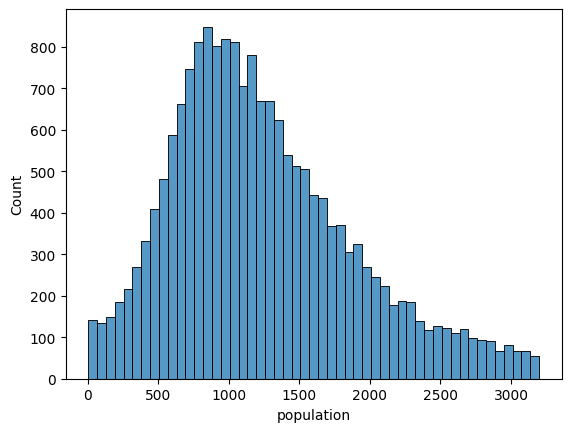

In [105]:
# the same here:
sns.histplot(df['population'])

In [106]:
df.to_csv("housing_trimmed_variables.csv", index=False)

In [107]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

In [108]:
variable = "median_income"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 3.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
2,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1
124,52.0,2612.0,901.0,7.2354,391100.0,17.84,0,0,0,1
126,50.0,2935.0,1031.0,7.5000,295200.0,18.95,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
20233,17.0,1986.0,761.0,7.2137,401900.0,55.32,1,0,0,0
20237,13.0,1841.0,833.0,7.7785,404700.0,54.03,1,0,0,0
20280,5.0,6123.0,2440.0,7.9013,393000.0,47.93,1,0,0,0
20296,27.0,534.0,243.0,8.2787,330000.0,55.88,1,0,0,0


In [109]:
print(len(inliers))
print(len(noise))
print(len(df))

17711
611
18322


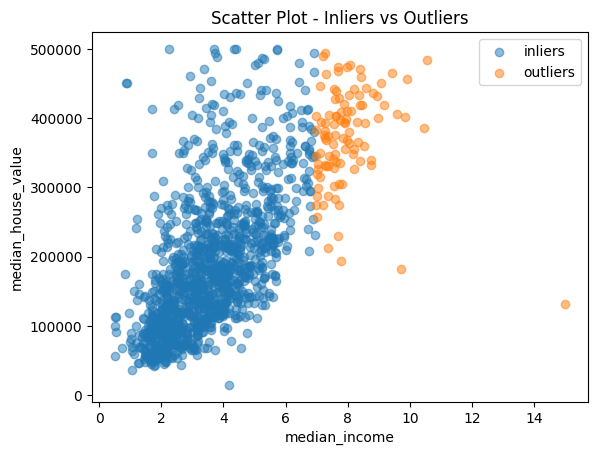

In [ ]:
#(I asked ChatGPT to help in visualization)
import matplotlib.pyplot as plt

variable = "median_income"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [111]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

In [112]:
variable = "distance_to_nearest_city"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 3.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1016,17.0,1364.0,338.0,2.4500,117600.0,251.98,0,1,0,0
1017,15.0,2061.0,573.0,2.2417,97900.0,241.45,0,1,0,0
1018,16.0,3045.0,202.0,3.1500,140600.0,227.20,0,1,0,0
1048,23.0,6010.0,2710.0,3.0068,107300.0,226.77,0,1,0,0
1050,17.0,5273.0,2446.0,1.9362,89900.0,227.27,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
19863,25.0,1009.0,994.0,1.8462,55800.0,223.14,0,1,0,0
19911,18.0,473.0,88.0,4.0833,137500.0,218.84,0,1,0,0
19912,17.0,346.0,51.0,3.4861,137500.0,250.82,0,1,0,0
20428,25.0,1665.0,845.0,1.5603,78100.0,221.99,0,1,0,0


In [113]:
print(len(inliers))
print(len(noise))
print(len(df))

16362
1960
18322


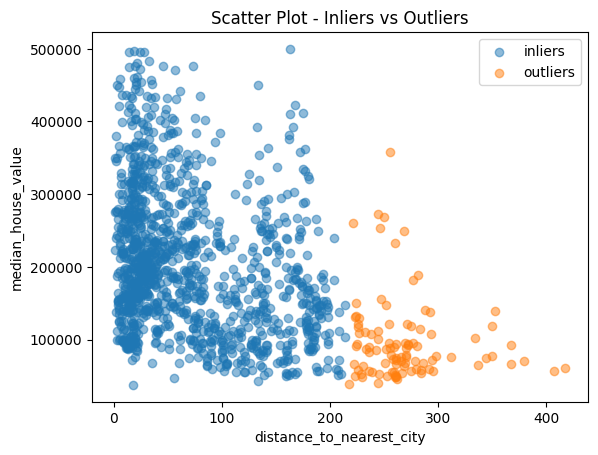

In [ ]:
# (I asked ChatGPT to help in visualization)
import matplotlib.pyplot as plt

variable = "distance_to_nearest_city"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [115]:
variable = "median_house_value"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 3.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,322.0,8.3252,452600.0,20.33,0,0,0,1
128,40.0,4991.0,1616.0,7.5544,411500.0,19.39,0,0,0,1
140,30.0,292.0,126.0,6.3624,483300.0,21.40,0,0,0,1
155,52.0,2315.0,861.0,8.8793,410300.0,17.09,0,0,0,1
404,52.0,2041.0,671.0,6.9414,417500.0,19.12,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
20183,16.0,6510.0,2304.0,7.9943,452100.0,62.61,1,0,0,0
20212,29.0,1326.0,586.0,6.5474,422900.0,58.77,1,0,0,0
20218,17.0,1822.0,578.0,5.4346,428600.0,69.73,0,0,0,0
20233,17.0,1986.0,761.0,7.2137,401900.0,55.32,1,0,0,0


In [116]:
print(len(inliers))
print(len(noise))
print(len(df))

17550
772
18322


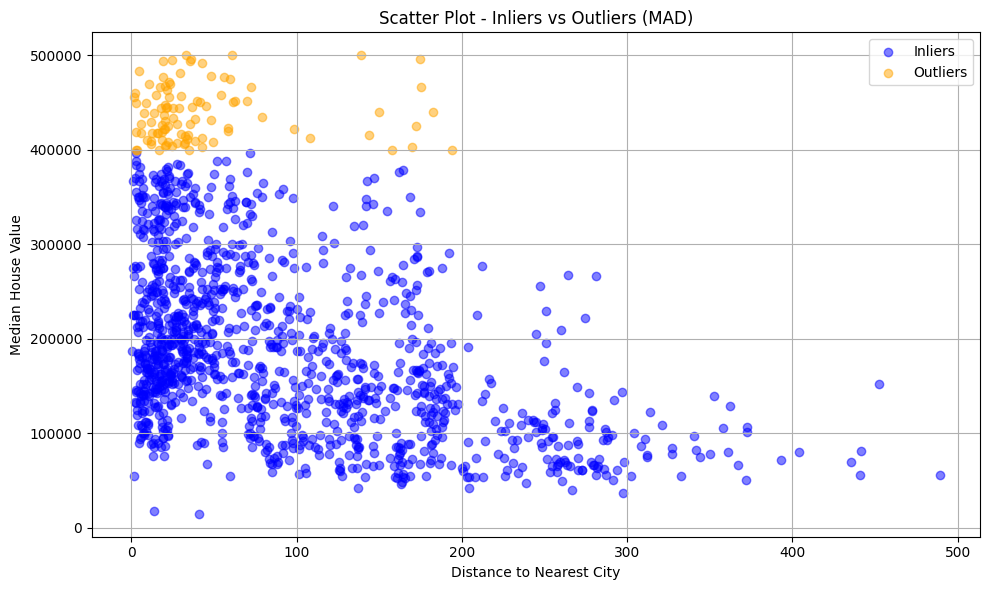

In [117]:
import matplotlib.pyplot as plt

# Variables to plot
variable = "distance_to_nearest_city"
target = "median_house_value"

# Safety: check how many samples exist before sampling
inliers_sample = inliers.sample(min(len(inliers), 1200), random_state=42)
outliers_sample = noise.sample(min(len(noise), 100), random_state=42)

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(inliers_sample[variable], inliers_sample[target], 
            label="Inliers", alpha=0.5, color='blue')

plt.scatter(outliers_sample[variable], outliers_sample[target], 
            label="Outliers", alpha=0.5, color='orange')

# Plot labels and title
plt.xlabel("Distance to Nearest City")
plt.ylabel("Median House Value")
plt.title("Scatter Plot - Inliers vs Outliers (MAD)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [118]:
variable = "total_rooms"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 3.5 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1,21.0,7099.0,2401.0,8.3014,358500.0,19.91,0,0,0,1
96,31.0,4596.0,2048.0,2.8345,183800.0,14.88,0,0,0,1
100,29.0,4656.0,2304.0,2.4912,257800.0,15.39,0,0,0,1
101,28.0,5806.0,2563.0,3.2177,273400.0,15.39,0,0,0,1
104,34.0,5871.0,2689.0,2.8406,335700.0,14.54,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
20334,13.0,6819.0,2828.0,4.6225,226500.0,105.80,0,1,0,0
20338,26.0,4802.0,2199.0,3.7452,227700.0,104.18,0,1,0,0
20360,15.0,6809.0,3060.0,5.3064,165000.0,112.74,0,1,0,0
20362,17.0,5320.0,2866.0,4.1997,133400.0,114.04,0,1,0,0


In [119]:
print(len(inliers))
print(len(noise))
print(len(df))

17248
1074
18322


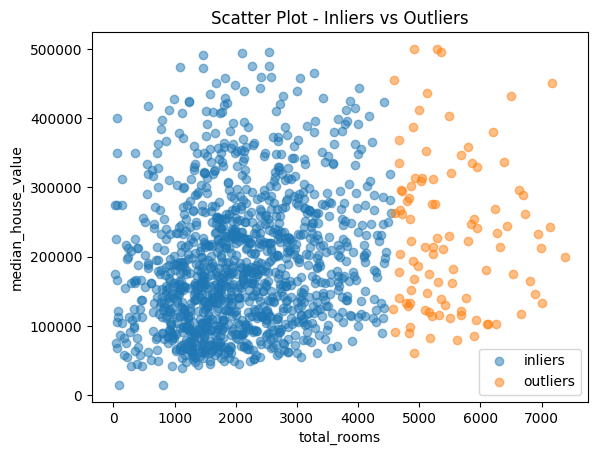

In [120]:
import matplotlib.pyplot as plt

variable = "total_rooms"
target = "median_house_value"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(1200)
outliers_sample = noise.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()